# NB00 — Data Survey

**Project**: `genotype_to_phenotype_enigma`
**Purpose**: Inventory and cross-link every data source that feeds this project, establish strain and condition tiers, and record the scale of the training corpus before any modeling notebooks begin.

This notebook is read-only: it loads pre-computed TSVs from `data/eda/` and displays summaries. The heavy Spark aggregations that produced those TSVs are documented at the bottom of the notebook.

## What we have

1. **ENIGMA growth curves** — newly uploaded to `enigma_coral.ddt_brick*` (bricks 928–1230). High-throughput OD time series across Oak Ridge field isolates under carbon/nitrogen/metal/antibiotic stress.
2. **Fitness Browser RB-TnSeq data** — gene-level fitness for 48 organisms under hundreds of conditions (`kescience_fitnessbrowser`). Mechanistic ground-truth for predictor validation.
3. **Carbon source phenotypes** — 795 genomes × 379 literature-curated binary phenotype calls with KofamScan KO annotations and BacFormer protein-language-model embeddings (`globalusers_carbon_source_phenotypes`). Joint KBase/BERDL project led by Dileep (preprint in prep).
4. **Pangenome, GapMind, ModelSEED, BacDive, WoM** — BERDL's existing curated feature and phenotype databases, already linked to FB through previous projects.
5. **CORAL strain/genome metadata** — 6,705 KBase narrative genomes for ENIGMA strains (`enigma_coral.sdt_genome`); 123 of these strains have growth curves in the bricks.

An ENIGMA-specific GenomeDepot is also being loaded by Alexey; when that arrives it will replace this notebook's CORAL-narrative-only fallback for Tier 2b strains.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)

EDA = Path('../data/eda')
FIG = Path('../figures')


## 1. ENIGMA growth corpus

303 plates across bricks 928–1230, ~7.5M timepoint rows, 27,632 growth curves (wells). Each plate tests a single strain against ~8–16 media backgrounds crossed with ~8–91 molecules (carbon sources, metals, antibiotics, nitrogen sources) at defined concentrations and sometimes varied pH.

In [2]:
brick = pd.read_csv(EDA / 'brick_summary.tsv', sep='\t')
print(f'Bricks: {len(brick)}')
print(f'Total timepoint rows: {brick.n_rows.sum():,}')
print(f'Total growth curves (wells): {brick.n_wells.sum():,}')
brick[['n_rows','n_wells','n_timepoints','t_max','od_max']].describe().round(2)


Bricks: 303
Total timepoint rows: 7,569,004
Total growth curves (wells): 27,632


,n_rows,n_wells,n_timepoints,t_max,od_max
count,303.00,303.00,303.00,303.00,303.00
mean,24980.21,91.19,271.38,68.25,0.88
std,6626.92,7.91,59.50,15.19,0.32
min,8736.00,74.00,91.00,22.74,0.20
25%,16598.00,86.00,193.00,48.24,0.67
50%,27360.00,96.00,289.00,72.24,0.85
75%,27744.00,96.00,289.00,72.33,1.04
max,36960.00,96.00,385.00,98.22,2.77


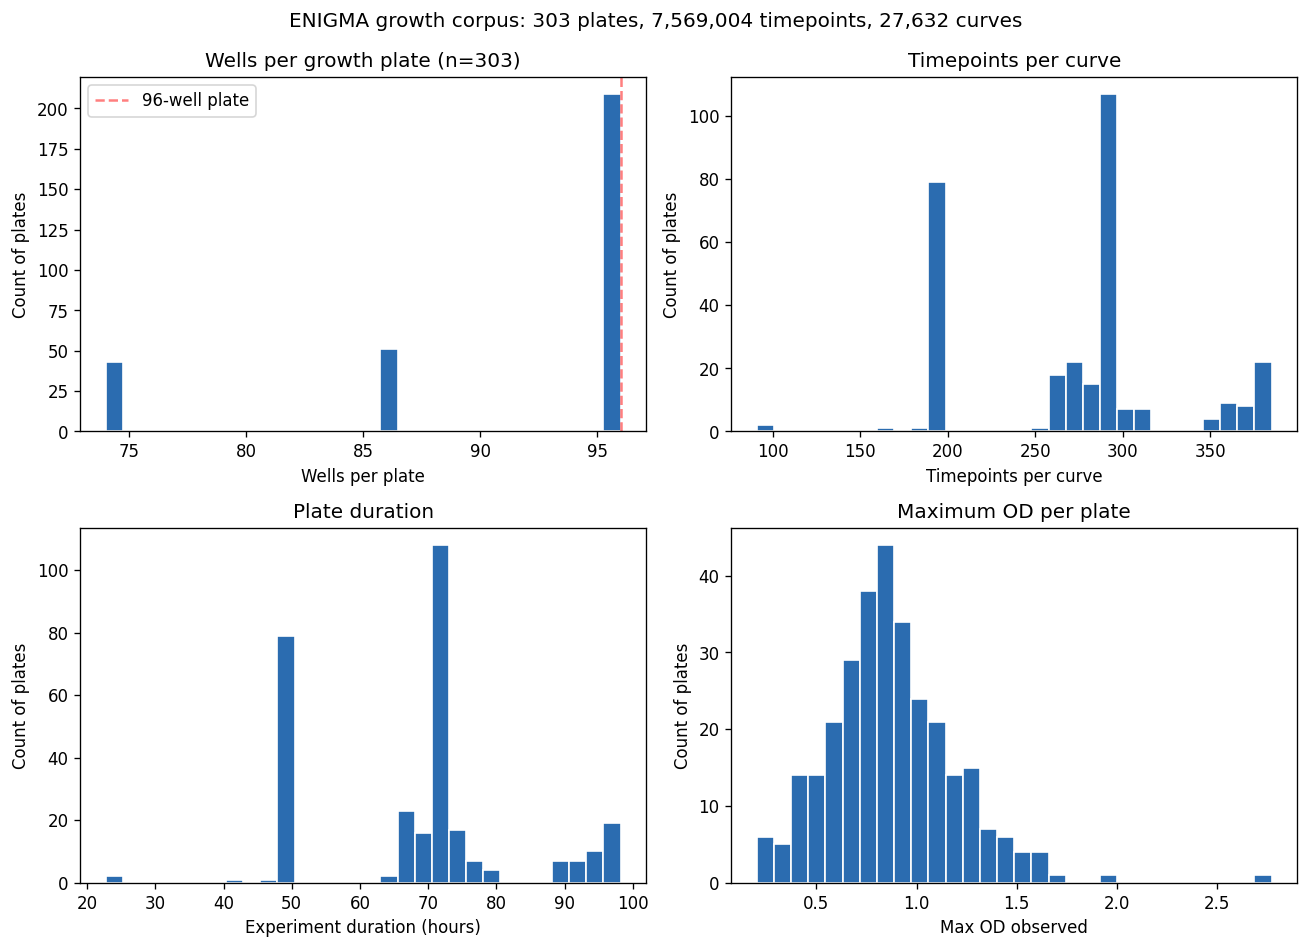

In [3]:
from IPython.display import Image
Image(filename=str(FIG / 'NB00_growth_corpus_stats.png'))


### 1.1 Per-strain curve counts

The brick data contains **123 distinct strain names** (more than the 88 we initially parsed from brick filenames, because some bricks contain strains whose names don't match the `YYYYMMDD_STRAIN_RELOADS_####` pattern). Top strains have 4–5 bricks × ~91 distinct molecules tested = very rich sampling.

In [4]:
per_strain = pd.read_csv(EDA / 'per_strain_summary.tsv', sep='\t')
print(f'Unique growth-curve strains: {len(per_strain)}')
per_strain.head(15)


Unique growth-curve strains: 123


,strain,n_bricks,total_curves,max_n_media,max_n_molecules,best_od
0,FW300-N2F2,5,458,16,91,1.027
1,FW300-N2E2,5,456,16,91,1.236
2,GW460-11-11-14-LB1,5,456,16,91,0.742
3,GW101-3H06,5,454,16,91,1.992
4,FW300-N2E3,5,454,16,91,1.266
5,GW821-FHT04C10,5,446,12,91,1.221
6,GW821-FHT01B05,5,426,16,91,0.906
7,GW821-FHT02D03,4,384,1,91,1.170
8,GW822-FHT03C01,4,384,1,91,1.585
9,EB271-G4-3-1,4,384,1,91,1.604


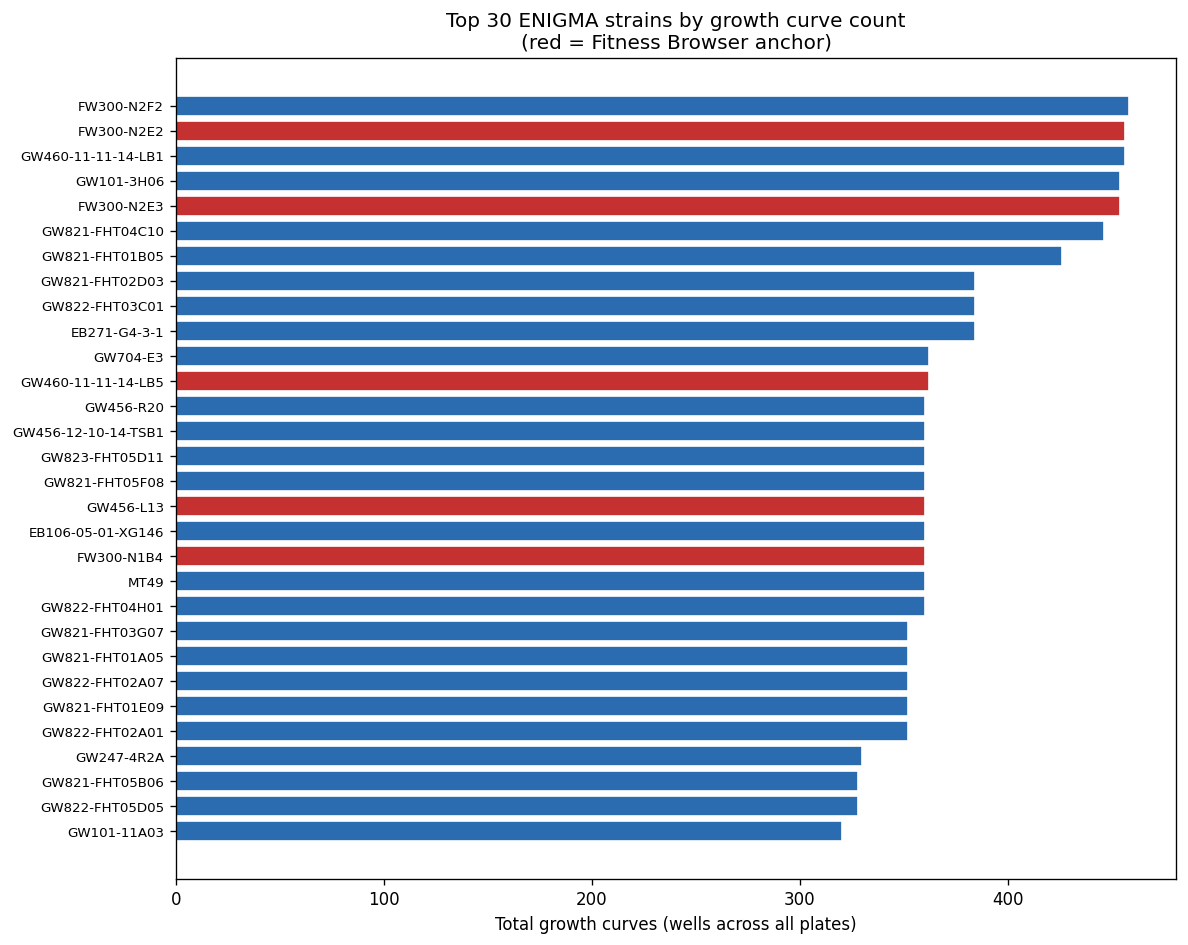

In [5]:
Image(filename=str(FIG / 'NB00_per_strain_curves.png'))


### 1.2 Molecule and media inventory

195 distinct molecules tested across all plates (with ChEBI IDs), spanning carbon sources, amino acids, metals, antibiotics, and nitrogen sources. 21 distinct base media including defined media (RCH2, UGA, NLDM, M9+variants) and rich media (LB, R2A). Several pH variants of NLDM are tested to probe pH stress.

In [6]:
mol = pd.read_csv(EDA / 'growth_molecules.tsv', sep='\t')
print(f'Distinct molecules: {len(mol)}')
mol.head(20)


Distinct molecules: 195


,molecule,chebi_curie,max_mM,min_mM,total_rows,n_brick_entries
0,glucose,CHEBI:17234,10.000,5.000,326277,303
1,2-hydroxypropanoic acid,CHEBI:78320,10.000,5.000,202809,260
2,erythromycin A,CHEBI:42355,NaN,NaN,140478,94
3,kanamycin A sulfate,CHEBI:6109,NaN,NaN,140478,94
4,sodium nitrate,CHEBI:63005,500.000,10.000,121854,108
5,nickel chloride hexahydrate,CHEBI:53542,1.736,0.217,101998,94
6,sucrose,CHEBI:17992,10.000,5.000,64837,144
7,D-xylopyranose,CHEBI:53455,10.000,5.000,64837,144
8,D-mannitol,CHEBI:16899,10.000,5.000,64837,144
9,sodium acetate,CHEBI:32954,10.000,5.000,64837,144


In [7]:
media = pd.read_csv(EDA / 'growth_media.tsv', sep='\t')
print(f'Distinct media: {len(media)}')
media


Distinct media: 21


,media_name,total_rows,n_brick_entries
0,RCH2_defined_noCarbon_ATCC,3026496,105
1,UGA_defined_nocarbon,2235130,172
2,UGA_PIPES_noCarbon,773376,26
3,R2A,484952,94
4,NLDM_defined,323896,94
5,NLDM_defined_nocarbon,119900,94
6,RCH2_defined_noCarbon,99322,94
7,M9 minimal media_noCarbon,90564,75
8,LB,80528,94
9,NLDM_defined_pH4.5,40264,94


## 2. Strain → genome → FB linkage

We need to know, for each of the 123 growth-curve strains, whether we have: (a) a Fitness Browser entry, (b) a BERDL pangenome genome, (c) a CORAL narrative genome. These tiers determine what predictor families can be applied.

The original plan assumed n=5 FB-anchor strains. The actual count with exact-name matching is **7**, adding `GW101-3H11 ↔ acidovorax_3H11` (Acidovorax sp.) and `FW507-4G11 ↔ Cup4G11` (Cupriavidus basilensis).

In [8]:
linkage = pd.read_csv(EDA / 'strain_linkage_master.tsv', sep='\t')
summary = {
    'Total growth-curve strains': len(linkage),
    'Tier 1 — growth + FB fitness + genome': int(linkage.has_fb.sum()),
    'Tier 2 — growth + BERDL pangenome (Tier 1 ⊂ Tier 2)': int(linkage.has_pangenome.sum()),
    'Tier 2/3 — growth + CORAL narrative genome': int(linkage.has_coral_genome.sum()),
    'No genome anywhere': int((~linkage.has_coral_genome & ~linkage.has_pangenome).sum()),
}
for k, v in summary.items():
    print(f'{k}: {v}')


Total growth-curve strains: 123
Tier 1 — growth + FB fitness + genome: 7
Tier 2 — growth + BERDL pangenome (Tier 1 ⊂ Tier 2): 32
Tier 2/3 — growth + CORAL narrative genome: 123
No genome anywhere: 0


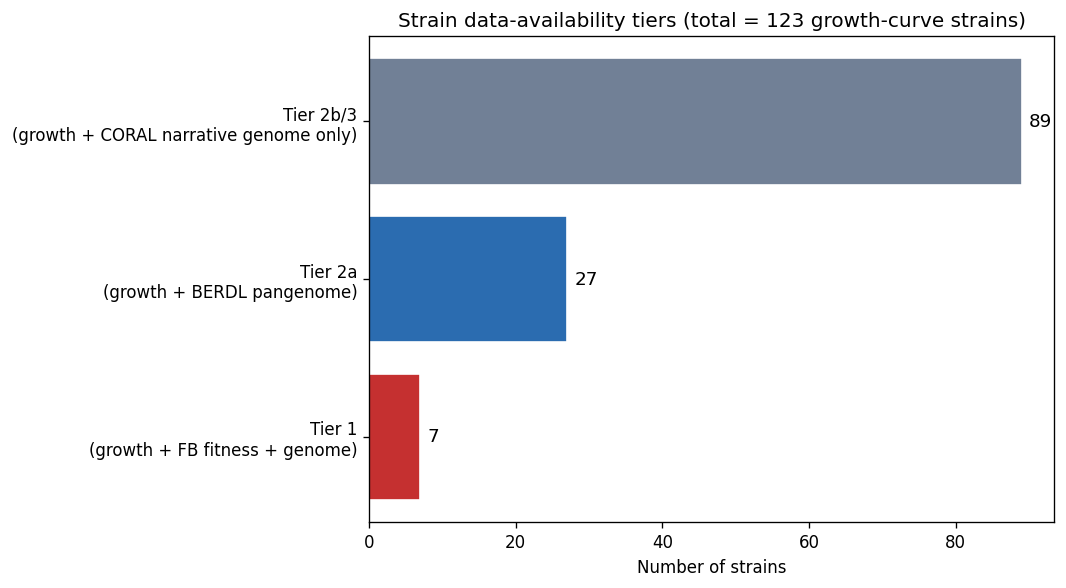

In [9]:
Image(filename=str(FIG / 'NB00_strain_tiers.png'))


In [10]:
# Tier 1 strains — the gold anchor set
linkage[linkage.has_fb].sort_values('total_curves', ascending=False)[
    ['strain','n_bricks','total_curves','max_n_media','max_n_molecules','best_od','orgId','genus','species']
]


,strain,n_bricks,total_curves,max_n_media,max_n_molecules,best_od,orgId,genus,species
1,FW300-N2E2,5,456,16,91,1.236,pseudo6_N2E2,Pseudomonas,fluorescens
4,FW300-N2E3,5,454,16,91,1.266,pseudo3_N2E3,Pseudomonas,fluorescens
11,GW460-11-11-14-LB5,4,362,16,91,0.775,Pedo557,Pedobacter,sp.
16,GW456-L13,4,360,16,91,1.506,pseudo13_GW456_L13,Pseudomonas,fluorescens
18,FW300-N1B4,4,360,16,91,1.234,pseudo1_N1B4,Pseudomonas,fluorescens
45,GW101-3H11,2,192,1,91,0.749,acidovorax_3H11,Acidovorax,sp.
48,FW507-4G11,2,192,1,91,1.200,Cup4G11,Cupriavidus,basilensis


## 3. Fitness Browser anchor coverage

For each Tier 1 FB anchor, how many distinct FB experiments (condition_1 values) exist, and how many of those conditions overlap with molecules tested in the ENIGMA growth corpus?

`pseudo3_N2E3` (FW300-N2E3) is the strongest anchor with 43 FB conditions, 19 of which overlap ENIGMA growth molecules after naive string matching.

In [11]:
fb_overlap = pd.read_csv(EDA / 'fb_anchor_conditions_overlapping_enigma.tsv', sep='\t')
per_anchor = fb_overlap.groupby('orgId').condition_1.nunique().to_frame('n_overlapping_conditions')
per_anchor


,n_overlapping_conditions
orgId,
Pedo557,5
pseudo13_GW456_L13,2
pseudo1_N1B4,6
pseudo3_N2E3,19
pseudo5_N2C3_1,13
pseudo6_N2E2,9


## 4. Cross-dataset condition linkage

After a naive lowercase/punctuation normalization, the three main datasets overlap in 19 conditions (present in all of ENIGMA, carbon-source-phenotypes, and FB), 82 pairs, and 566 unique conditions. The 19 triple-overlap set is the strongest cross-dataset "super-anchor" for validating that growth prediction, curated literature phenotype, and gene-fitness all agree.

Note: this is before proper ChEBI ID matching — real overlap will be higher after the canonicalization in NB02.

In [12]:
cross = pd.read_csv(EDA / 'cross_dataset_conditions.tsv', sep='\t')
print(f'Unique normalized conditions: {len(cross)}')
print(f'  in all 3 datasets: {(cross.n_datasets == 3).sum()}')
print(f'  in 2 datasets: {(cross.n_datasets == 2).sum()}')
print(f'  in 1 dataset only: {(cross.n_datasets == 1).sum()}')


Unique normalized conditions: 667
  in all 3 datasets: 19
  in 2 datasets: 82
  in 1 dataset only: 566


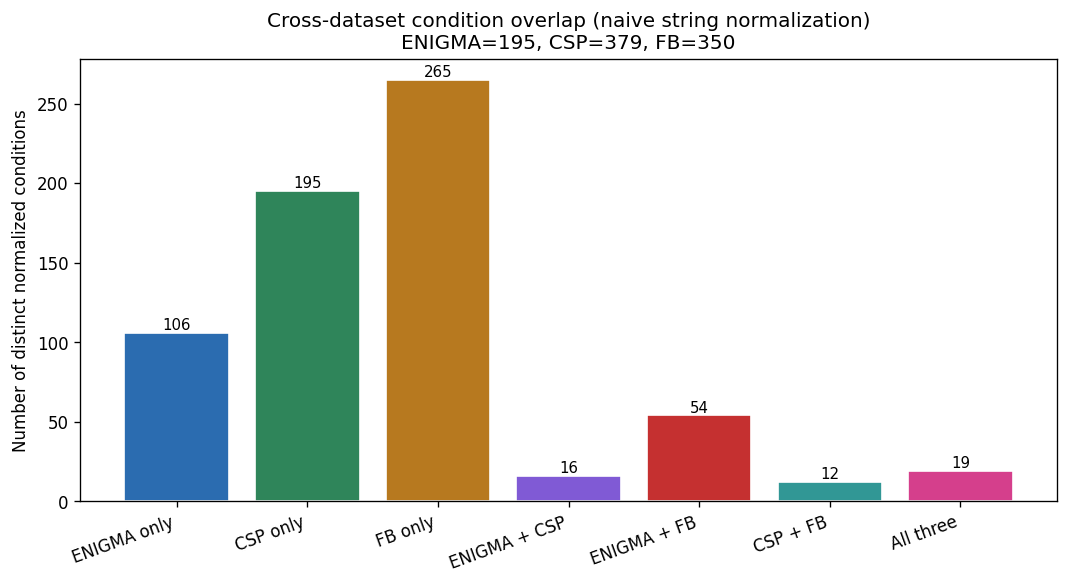

In [13]:
Image(filename=str(FIG / 'NB00_condition_overlap.png'))


In [14]:
# Triple-overlap conditions (the super-anchor set)
triple = cross[cross.n_datasets == 3][['enigma_name','csp_name','fb_condition','enigma_chebi']]
triple.reset_index(drop=True)


,enigma_name,csp_name,fb_condition,enigma_chebi
0,lactulose,Lactulose,Lactulose,CHEBI:6359
1,glycerol,Glycerol,Glycerol,CHEBI:17754
2,glycine,Glycine,Glycine,CHEBI:15428
3,thymidine,Thymidine,Thymidine,CHEBI:17748
4,xylitol,Xylitol,Xylitol,CHEBI:17151
5,citric acid,Citric-Acid,Citric Acid,CHEBI:30769
6,N-acetyl-D-glucosamine,N-Acetyl-D-Glucosamine,N-Acetyl-D-Glucosamine,CHEBI:506227
7,succinic acid,Succinic-Acid,Succinic Acid,CHEBI:15741
8,inosine,Inosine,Inosine,CHEBI:17596
9,ethanol,Ethanol,Ethanol,CHEBI:16236


## 5. Carbon source phenotype corpus (`globalusers_carbon_source_phenotypes`)

A joint KBase/BERDL-curated dataset, preprint in preparation (led by Dileep). Key scale:
- **795 genomes** with measured phenotype data (1,097 total in the genome table)
- **379 distinct phenotype IDs** across 4 media contexts: `lit` (literature), `pmi` (plant-microbe interaction, 176 phenotypes), `atleaf` (Arabidopsis leaf, 44), `marine` (100 but no measurements in joined table)
- **~53,000 binary (grow/no-grow) measurements**: 39.4% positive, 53.6% negative, 7.0% NULL
- **Pre-computed features**: KofamScan KO annotations (5.2M gene→KO rows) + BacFormer protein-language-model embeddings (~480 dim per genome) + GTDB-style taxonomy
- **Phylum coverage**: 389 Proteobacteria, 115 Actinobacteriota, 19 Bacteroidota, 17 Firmicutes, 15 Campylobacterota — Proteobacteria-heavy, which aligns well with the ENIGMA Pseudomonas-dominated growth curves.

None of the 7 Tier 1 anchor strains are in the CSP corpus directly (Oak Ridge field isolates vs. PATRIC/BV-BRC genomes). However, at the **species-clade level** (GTDB), 54 CSP genomes share a genus with a Tier 2 ENIGMA strain, and 5 CSP genomes share the exact species clade with a Tier 1 anchor. These are natural sister-genome training points for within-species transfer tests.

In [15]:
csp = pd.read_csv(EDA / 'csp_phenotypes.tsv', sep='\t')
print(f'Phenotype descriptions: {len(csp)}')
csp.head(15)


Phenotype descriptions: 379


,phenotypeid,name,description
0,glucose-lit,Glucose,Growth on glucose-lit (medium: lit)
1,acetic-acid-lit,Acetic-Acid,Growth on acetic-acid-lit (medium: lit)
2,dextrin-lit,Dextrin,Growth on dextrin-lit (medium: lit)
3,galactonic-acid-g-lactone-lit,Galactonic-Acid-g-Lactone,Growth on galactonic-acid-g-lactone-lit (mediu...
4,mucic-acid-lit,Mucic-Acid,Growth on mucic-acid-lit (medium: lit)
5,inosine-lit,Inosine,Growth on inosine-lit (medium: lit)
6,neuraminic-acid-lit,Neuraminic-Acid,Growth on neuraminic-acid-lit (medium: lit)
7,acetoacetic-acid-lit,Acetoacetic-Acid,Growth on acetoacetic-acid-lit (medium: lit)
8,glycyl-l-proline-lit,Glycyl-L-Proline,Growth on glycyl-l-proline-lit (medium: lit)
9,mannose-lit,Mannose,Growth on mannose-lit (medium: lit)


## 6. Implications for the research plan

This survey changes several assumptions in `RESEARCH_PLAN.md` v1:

1. **Tier 1 anchor size**: 7 strains, not 5 (added GW101-3H11 / FW507-4G11). Both new anchors have fewer curves but still contribute to cross-strain validation.
2. **Tier 2 expansion**: 32 strains with BERDL pangenome links (was 22), driven by using the 123 true strain list rather than 88.
3. **Genome coverage is complete**: all 123 growth-curve strains have a CORAL narrative genome link. No strain has "growth curves only" — the limiting factor for genome features is whether we have pre-computed features in BERDL, not whether a genome exists.
4. **Primary training corpus shifts**: `globalusers_carbon_source_phenotypes` (795 genomes × ~53K binary labels) is a much better training cohort than the original "5 anchor strains" plan. The ENIGMA growth curves become a **continuous-target, out-of-distribution evaluation set** rather than the primary training data.
5. **Cross-dataset condition overlap is real**: 19 conditions are in all three datasets (naive string match); after ChEBI canonicalization this number will grow substantially. The 73-condition ENIGMA∩FB overlap is particularly promising — roughly 21% of FB's 350 conditions also appear in ENIGMA.
6. **FB-anchor coverage varies 5x**: pseudo3_N2E3 has 43 FB conditions; pseudo13_GW456_L13 has 9. Downstream per-anchor statistics must be weighted accordingly.

## 7. What's still missing / pending

- **ENIGMA GenomeDepot (Alexey)** — not yet loaded. Will give us Tier 2 features (annotations, KO, pangenome membership) for all 123 strains instead of the 32 currently covered.
- **Access to `u_janakakbase__growthphenos`** — returns `AccessDeniedException` on `s3a://cdm-lake/users-general-warehouse/janakakbase/...`. This may be a parallel phenotype schema (condition_set / experiment / measurement / protocol / experimental_variable / experimental_context) that should be reviewed after we get access. Worth asking Janaka.
- **ChEBI-based condition canonicalization (NB02)** — the naive string normalization already gives 19 triple-overlap conditions; proper ChEBI ID matching (using the ENIGMA brick `sys_oterm_id` field) will likely bring this to 40–60.
- **Growth-curve fitting (NB01)** — data is clean and scale is tractable; deferred to the next notebook.

## 8. Provenance notes

- **Brick aggregation SQL** was built by parallel chunks of 30 bricks each, UNION ALL'd into a single query to collapse row counts and distinct counts without pulling timepoint data to the driver. The full brick-summary script is in the git log under `data/eda/brick_summary.tsv`.
- **Strain linkage** uses three sources: FB organism table exact match, `gtdb_metadata.ncbi_strain_identifiers` for pangenome, and `enigma_coral.sdt_genome.sdt_strain_name` for CORAL narrative genomes.
- **Cross-dataset condition overlap** was computed on normalized strings (lowercase, strip `- _ , ( )`); proper ChEBI / ModelSEED canonicalization is deferred to NB02.
- **No FBA, no GapMind, no KO feature extraction yet** — all feature engineering is deferred to NB06.
